# 三、无监督学习
无监督学习处理无标签数据，目标是发现数据内在的结构。

In [13]:
#导入模块
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 数据集
from sklearn.datasets import load_iris, load_digits, make_blobs, make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 无监督学习模型
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 评估指标
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
#解决中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False    

## 1.K-Means聚类

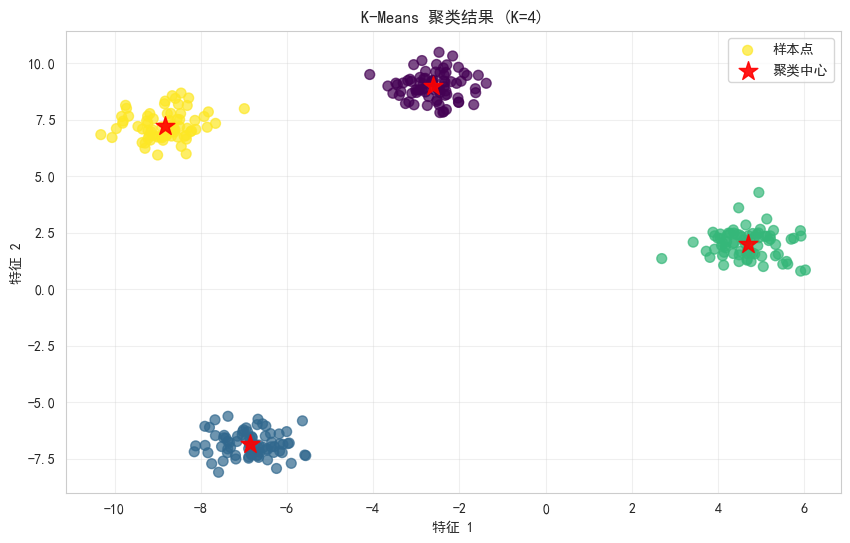

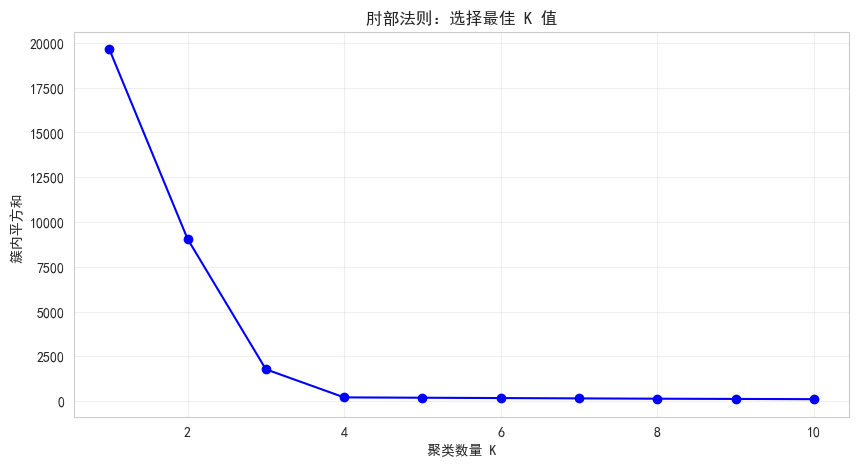

In [8]:
# 1. 生成聚类数据
X_cluster, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.6, 
                               random_state=42, n_features=2)

# 2. K-Means 聚类
kmeans = KMeans(n_clusters=4, random_state=42)
y_kmeans = kmeans.fit_predict(X_cluster)
centers = kmeans.cluster_centers_

# 3. 可视化聚类结果
plt.figure(figsize=(10, 6))
plt.scatter(X_cluster[:, 0], X_cluster[:, 1], c=y_kmeans, s=50, 
            cmap='viridis', alpha=0.7, label='样本点')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.9, 
            marker='*', label='聚类中心')
plt.xlabel('特征 1')
plt.ylabel('特征 2')
plt.title('K-Means 聚类结果 (K=4)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 4. 肘部法则选择最佳 K
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('聚类数量 K')
plt.ylabel('簇内平方和 ')
plt.title('肘部法则：选择最佳 K 值')
plt.grid(alpha=0.3)
plt.show()

解析：<br/>
1.肘部法则：肘部法则是选取参数K的常用方法。通过遍历不同聚类数量K，计算对应的簇内平方和 ，并绘制变化曲线。簇内平方和随K增大持续递减；当曲线下降速率显著放缓形成“手肘”拐点时，该拐点对应的 K 即为较合理的聚类数目，在簇内紧凑程度与聚类数量之间取得平衡。<br/>
2.原理：<br/>
* 在拐点之前：增加簇数量，能够优化分组，样本聚合显著提升；
* 在拐点之后：再增加簇，只能把原本紧凑的簇强行拆成更小的组,过度聚类。

## 2.层次聚类
原理：<br/>
层次聚类不需要预先指定簇数，分为下面两种：
* 凝聚式（自底向上）：每个样本初始单独为一簇，不断合并最近的两个簇
* 分裂式（自顶向下）：所有样本初始为一簇，不断分裂

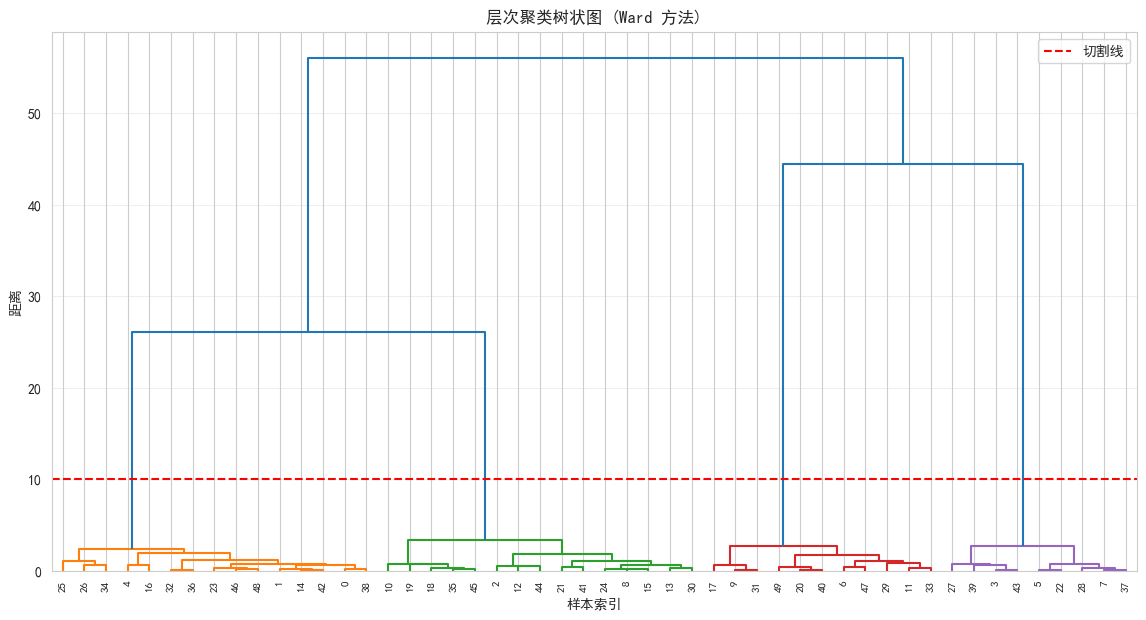

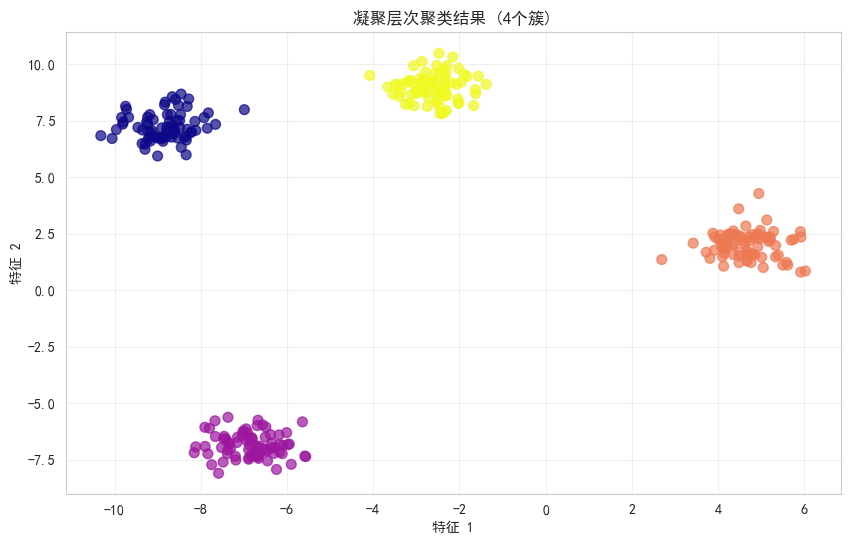

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. 数据（使用前面的 blobs 数据，取前50个便于观察）
X_hc = X_cluster[:50]

# 2. 计算链接矩阵（ward 方法：最小化簇内方差）
Z = linkage(X_hc, method='ward')

# 3. 绘制树状图
plt.figure(figsize=(14, 7))
dendrogram(Z, leaf_rotation=90, leaf_font_size=8, 
           color_threshold=10)
plt.xlabel('样本索引')
plt.ylabel('距离')
plt.title('层次聚类树状图 (Ward 方法)')
plt.axhline(y=10, color='r', linestyle='--', label='切割线')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.show()

# 4. 使用 sklearn 进行凝聚聚类并可视化
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
y_agg = agg.fit_predict(X_cluster)

plt.figure(figsize=(10, 6))
plt.scatter(X_cluster[:, 0], X_cluster[:, 1], c=y_agg, s=50, 
            cmap='plasma', alpha=0.7)
plt.xlabel('特征 1')
plt.ylabel('特征 2')
plt.title('凝聚层次聚类结果 (4个簇)')
plt.grid(alpha=0.3)
plt.show()

解析：<br/>
* 树状图的高度代表两个簇合并时的距离
* 红色虚线是切割线，切在不同高度可以得到不同数量的簇

## 3.PCA主成分分析
PCA 是最常用的线性降维方法，通过正交变换将高维数据投影到低维空间，保留数据中方差最大的方向（即主成分），从而实现数据压缩和可视化。

前两个主成分解释的方差比例: [0.12033916 0.09561054]
累计解释方差比例: 21.59%


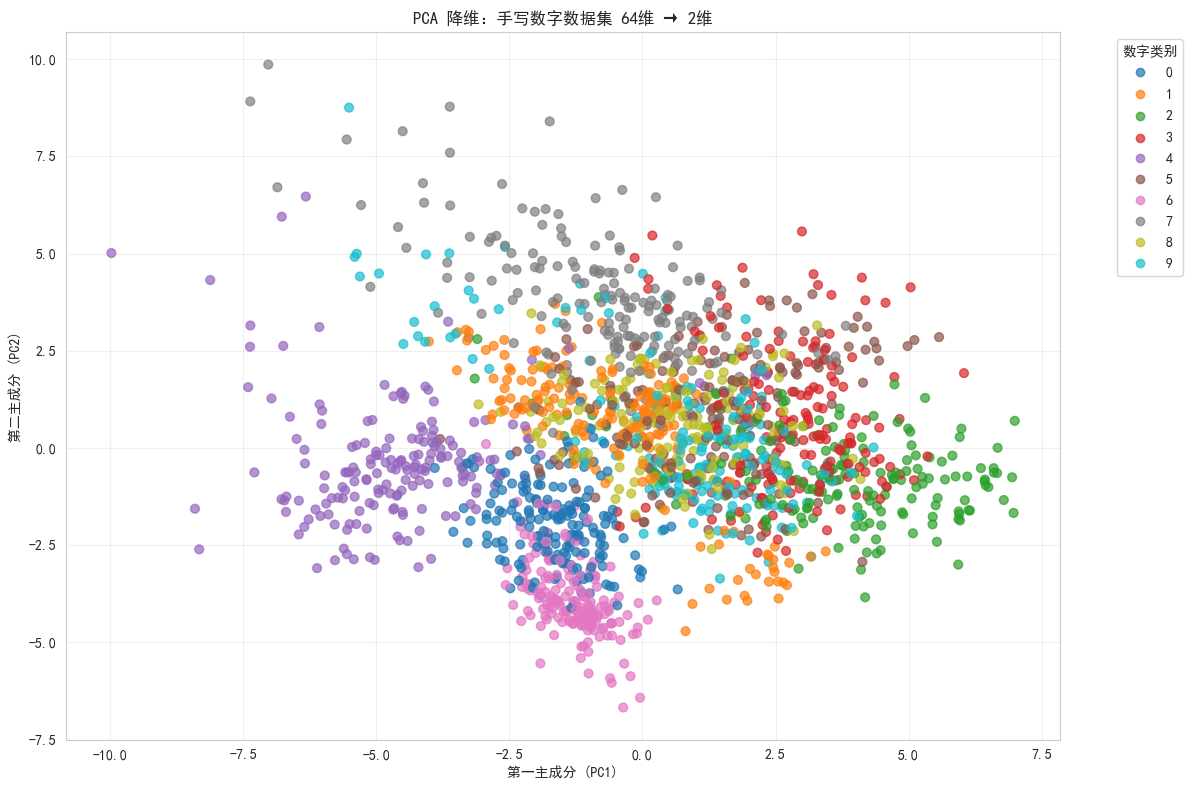

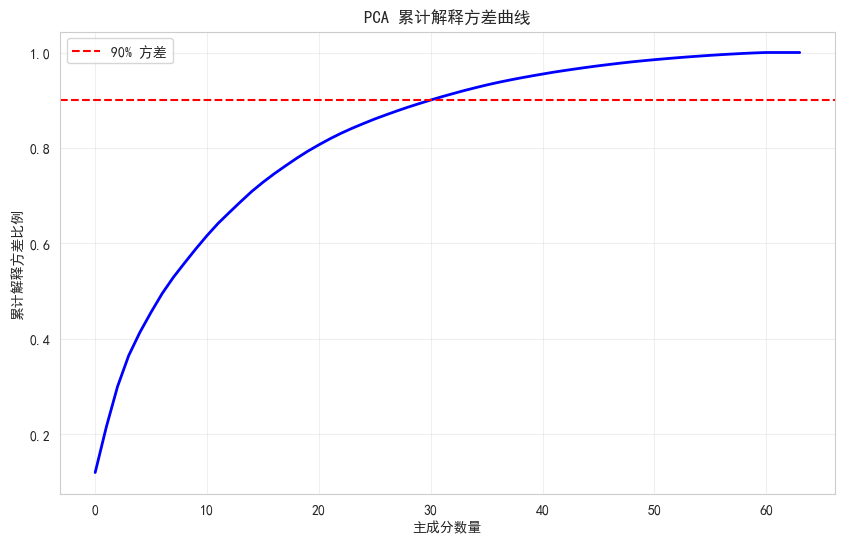

In [15]:
# 1. 使用高维手写数字数据 (64维)
digits = load_digits()
X = digits.data
y = digits.target

# 2. 标准化（PCA 对尺度敏感）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA 降维到 2 维
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"前两个主成分解释的方差比例: {pca.explained_variance_ratio_}")
print(f"累计解释方差比例: {sum(pca.explained_variance_ratio_):.2%}")

# 4. 可视化降维结果
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', 
                      alpha=0.7, s=40)
plt.xlabel('第一主成分 (PC1)')
plt.ylabel('第二主成分 (PC2)')
plt.title('PCA 降维：手写数字数据集 64维 → 2维')
plt.legend(*scatter.legend_elements(), title='数字类别', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. 累计解释方差曲线
pca_full = PCA().fit(X_scaled)
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), 'b-', linewidth=2)
plt.xlabel('主成分数量')
plt.ylabel('累计解释方差比例')
plt.title('PCA 累计解释方差曲线')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% 方差')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

解析：<br/>
上述实验对手写数字64维像素特征标准化后进行 PCA 降维。一方面将数据降至二维，实现可视化，直观观察各类样本在主成分空间的分布；另一方面通过方差解释率定量评估信息保留量，并绘制累计方差曲线，用于指导选择最优降维维度，平衡特征维度与原始信息保留程度。

## 4.t-SNE（t 分布邻域嵌入）
t-SNE 是非线性降维算法，核心思想是保持高维空间中样本的局部邻域关系，在低维空间中用 t 分布模拟高维的高斯分布，解决拥挤问题。

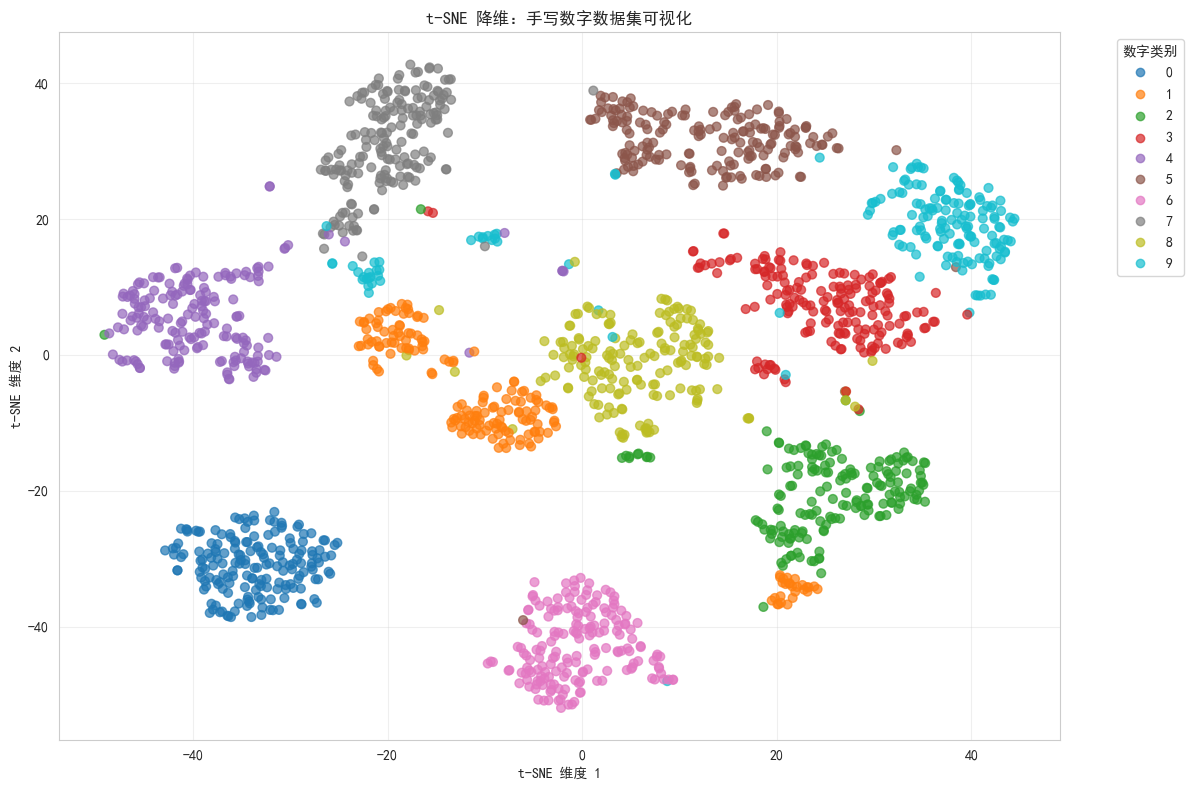

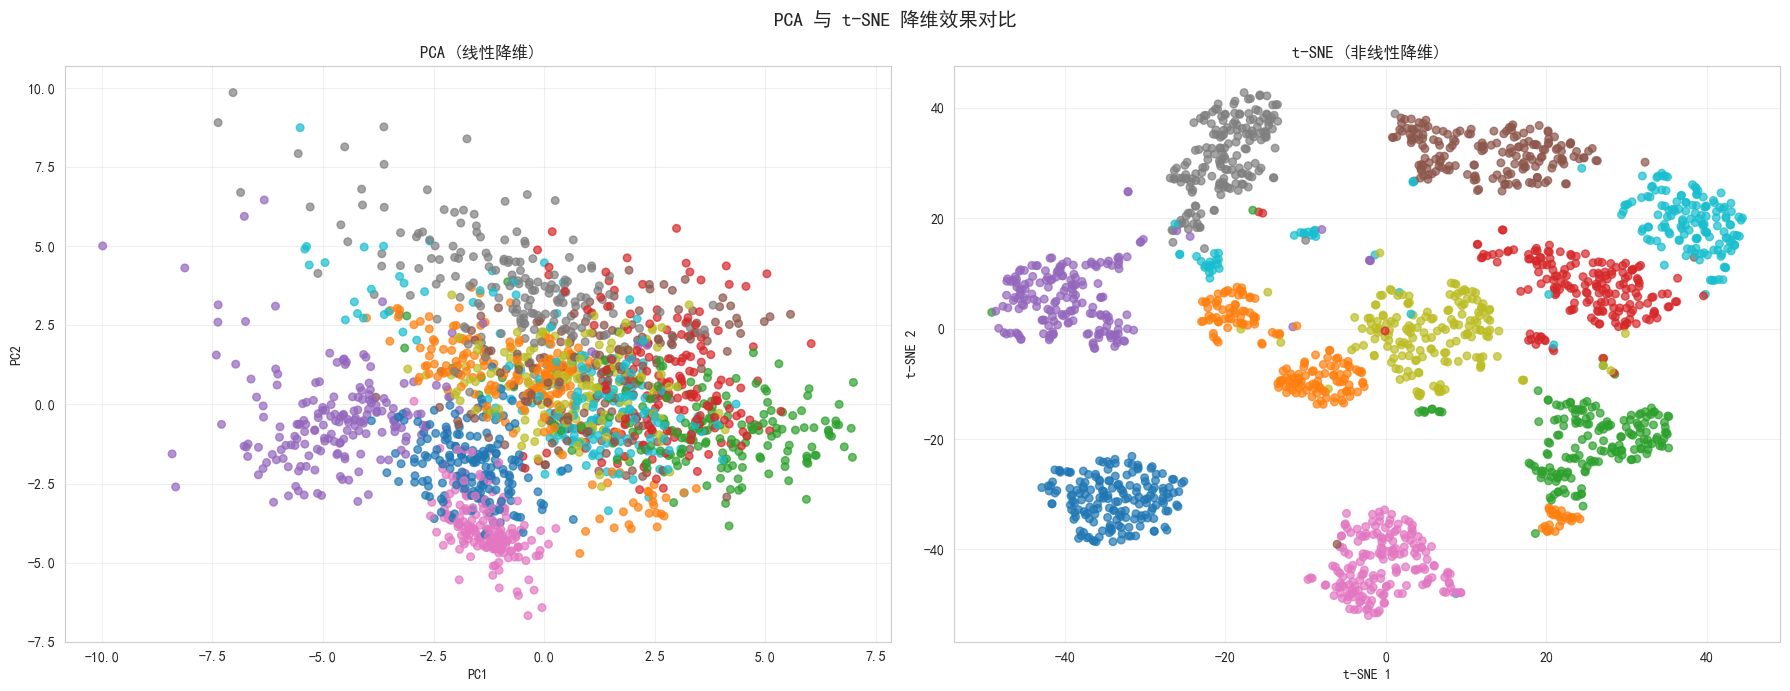

In [16]:
# 1. t-SNE 降维到 2 维
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# 2. 可视化
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', 
                      alpha=0.7, s=40)
plt.xlabel('t-SNE 维度 1')
plt.ylabel('t-SNE 维度 2')
plt.title('t-SNE 降维：手写数字数据集可视化')
plt.legend(*scatter.legend_elements(), title='数字类别', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. PCA 与 t-SNE 对比图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7, s=30)
ax1.set_title('PCA (线性降维)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.grid(alpha=0.3)

sc2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.7, s=30)
ax2.set_title('t-SNE (非线性降维)')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.grid(alpha=0.3)

fig.suptitle('PCA 与 t-SNE 降维效果对比', fontsize=14)
plt.tight_layout()
plt.show()

解析：<br/>
* t-SNE 聚类效果通常比 PCA 更清晰，因为它保留了局部结构
* t-SNE 计算慢、结果有随机性,每次运行略有不同，主要用于可视化，不用于特征工程
* perplexity 是重要参数，可以理解为 "近邻数量"，通常在 5-50 之间